# GAM Model - Clean Export Version

This notebook does four things:

1. Fits the plain-vanilla GAM on `training.csv`
2. Scores `test.csv`
3. Exports:
   - `gam_predictions_clean.csv`
   - `gam_store_category_metrics.csv`
4. Saves top-5 GAM interpretability plots to `gam_top5_interpretability/`


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pygam import LinearGAM, s, l
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_DIR = Path(".")
TRAIN_FILE = DATA_DIR / "training.csv"
TEST_FILE = DATA_DIR / "test.csv"

assert TRAIN_FILE.exists(), f"Missing file: {TRAIN_FILE}"
assert TEST_FILE.exists(), f"Missing file: {TEST_FILE}"


In [2]:

# -----------------------------
# Load data
# -----------------------------
train = pd.read_csv(TRAIN_FILE, parse_dates=["week_start"])
test = pd.read_csv(TEST_FILE, parse_dates=["week_start"])

target = "weekly_units"
drop_cols = ["weekly_units", "week_start"]
feature_cols = [c for c in train.columns if c not in drop_cols]

X_train = train[feature_cols].copy()
y_train = train[target].copy()

X_test = test[feature_cols].copy()
y_test = test[target].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (6510, 43)
X_test shape: (240, 43)


In [3]:

# -----------------------------
# Define GAM structure
# -----------------------------
smooth_cols = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_52",
    "rolling_mean_4",
    "rolling_std_4",
    "rolling_mean_8",
    "momentum",
    "recent_cv",
    "time_index",
    "avg_price",
    "price_rolling_4",
    "price_relative",
    "store_traffic_lag1",
    "cat_share_lag1",
]

linear_cols = [c for c in feature_cols if c not in smooth_cols]

col_index = {col: i for i, col in enumerate(feature_cols)}

terms = None
for col in feature_cols:
    idx = col_index[col]
    term = s(idx) if col in smooth_cols else l(idx)
    terms = term if terms is None else terms + term

gam = LinearGAM(terms)
gam.fit(X_train.values, y_train.values)

train_pred = gam.predict(X_train.values)
test_pred = gam.predict(X_test.values)

def regression_metrics(y_true, y_pred, label="dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mean_sales = np.mean(y_true)
    nrmse = 100 * rmse / mean_sales if mean_sales != 0 else np.nan

    print(f"\n{label} metrics")
    print("-" * 40)
    print(f"RMSE : {rmse:.3f}")
    print(f"MAE  : {mae:.3f}")
    print(f"NRMSE% of mean sales: {nrmse:.3f}")

regression_metrics(y_train, train_pred, "Train")
regression_metrics(y_test, test_pred, "Test")



Train metrics
----------------------------------------
RMSE : 691.456
MAE  : 448.178
NRMSE% of mean sales: 8.217

Test metrics
----------------------------------------
RMSE : 957.190
MAE  : 595.593
NRMSE% of mean sales: 9.533


In [4]:

# -----------------------------
# Reconstruct store and category labels
# -----------------------------
store_cols = [
    "store_id_CA_1", "store_id_CA_2", "store_id_CA_3", "store_id_CA_4",
    "store_id_TX_1", "store_id_TX_2", "store_id_TX_3",
    "store_id_WI_1", "store_id_WI_2", "store_id_WI_3",
]

def get_store(row):
    for c in store_cols:
        if row[c] == 1:
            return c.replace("store_id_", "")
    return "UNKNOWN"

def get_category(row):
    if row["cat_id_FOODS"] == 1:
        return "FOODS"
    elif row["cat_id_HOBBIES"] == 1:
        return "HOBBIES"
    elif row["cat_id_HOUSEHOLD"] == 1:
        return "HOUSEHOLD"
    return "UNKNOWN"

results = test.copy()
results["store_id"] = results.apply(get_store, axis=1)
results["category_id"] = results.apply(get_category, axis=1)
results["actual_units"] = y_test.values
results["predicted_units"] = np.rint(test_pred).astype(int)
results["predicted_units"] = results["predicted_units"].clip(lower=0)
results["predicted_units_raw"] = test_pred

results[["week_start", "store_id", "category_id", "actual_units", "predicted_units"]].head()


,week_start,store_id,category_id,actual_units,predicted_units
0,2016-03-26,CA_1,FOODS,20496,21942
1,2016-04-02,CA_1,FOODS,22389,21224
2,2016-04-09,CA_1,FOODS,20850,20942
3,2016-04-16,CA_1,FOODS,20842,20965
4,2016-04-23,CA_1,FOODS,21064,20908


In [5]:

# -----------------------------
# Export file 1:
# Weekstart date | Store ID | Category ID | Actual Units | Predicted units
# -----------------------------
predictions_clean = (
    results[["week_start", "store_id", "category_id", "actual_units", "predicted_units"]]
    .sort_values(["week_start", "store_id", "category_id"])
    .reset_index(drop=True)
)

predictions_clean.to_csv("gam_predictions_clean.csv", index=False)
print("Saved: gam_predictions_clean.csv")
print(predictions_clean.head(10))


Saved: gam_predictions_clean.csv
  week_start store_id category_id  actual_units  predicted_units
0 2016-03-26     CA_1       FOODS         20496            21942
1 2016-03-26     CA_1     HOBBIES          3756             3597
2 2016-03-26     CA_1   HOUSEHOLD          6647             7253
3 2016-03-26     CA_2       FOODS         21158            16637
4 2016-03-26     CA_2     HOBBIES          2876             2720
5 2016-03-26     CA_2   HOUSEHOLD          7988             6817
6 2016-03-26     CA_3       FOODS         27775            28610
7 2016-03-26     CA_3     HOBBIES          3957             4341
8 2016-03-26     CA_3   HOUSEHOLD         12123            12627
9 2016-03-26     CA_4       FOODS         11768            12368


In [6]:

# -----------------------------
# Accuracy metrics
# -----------------------------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def metric_table(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mean_sales = np.mean(y_true)
    return {
        "RMSE": rmse,
        "MAE": mae,
        "NRMSE_%_of_mean_sales": (100 * rmse / mean_sales) if mean_sales != 0 else np.nan,
        "MAE_%_of_mean_sales": (100 * mae / mean_sales) if mean_sales != 0 else np.nan,
        "MAPE_%": mape(y_true, y_pred),
        "sMAPE_%": smape(y_true, y_pred),
        "Mean_Sales": mean_sales,
        "n_weeks": len(y_true),
    }


In [7]:

# -----------------------------
# Overall metrics
# Team-comparable headline metrics + relative error metrics
# -----------------------------
overall_metrics = pd.DataFrame([{
    "model": "GAM (Plain Vanilla)",
    **metric_table(results["actual_units"], results["predicted_units_raw"])
}])

overall_metrics = overall_metrics[[
    "model",
    "MAE",
    "RMSE",
    "MAPE_%",
    "sMAPE_%",
    "NRMSE_%_of_mean_sales",
    "MAE_%_of_mean_sales",
    "Mean_Sales",
    "n_weeks",
]].rename(columns={
    "MAPE_%": "MAPE",
    "sMAPE_%": "sMAPE",
})

overall_metrics.to_csv("gam_overall_metrics.csv", index=False)

print("Saved: gam_overall_metrics.csv")
display(overall_metrics.round(3))


Saved: gam_overall_metrics.csv


,model,MAE,RMSE,MAPE,sMAPE,NRMSE_%_of_mean_sales,MAE_%_of_mean_sales,Mean_Sales,n_weeks
0,GAM (Plain Vanilla),595.593,957.19,7.305,7.758,9.533,5.932,10040.654,240


In [8]:

# -----------------------------
# Export file 2:
# Category | Store | Accuracy measures (R2 removed)
# -----------------------------
store_category_metrics = (
    results.groupby(["category_id", "store_id"], sort=True)
    .apply(lambda g: pd.Series(metric_table(g["actual_units"], g["predicted_units_raw"])))
    .reset_index()
    .rename(columns={"category_id": "Category", "store_id": "Store"})
    .sort_values(["Category", "Store"])
    .reset_index(drop=True)
)

store_category_metrics.to_csv("gam_store_category_metrics.csv", index=False)
print("Saved: gam_store_category_metrics.csv")
print(store_category_metrics)


Saved: gam_store_category_metrics.csv
     Category Store         RMSE          MAE  NRMSE_%_of_mean_sales  MAE_%_of_mean_sales     MAPE_%    sMAPE_%  Mean_Sales  n_weeks
0       FOODS  CA_1  1410.406506  1024.106854               6.447278             4.681417   4.560027   4.699446   21876.000      8.0
1       FOODS  CA_2  2604.631024  2236.197959              12.343053            10.597090  10.541938  11.355426   21102.000      8.0
2       FOODS  CA_3   794.283815   715.209214               2.865253             2.580003   2.586534   2.600114   27721.250      8.0
3       FOODS  CA_4   468.995017   394.389808               3.758123             3.160301   3.125231   3.162589   12479.500      8.0
4       FOODS  TX_1   788.844613   700.227506               5.206122             4.621277   4.586932   4.719318   15152.250      8.0
5       FOODS  TX_2   793.751762   636.894878               4.276392             3.431315   3.375642   3.431845   18561.250      8.0
6       FOODS  TX_3   988.55573

In [9]:

# -----------------------------
# Consolidated Excel export
# -----------------------------
with pd.ExcelWriter("gam_outputs.xlsx", engine="openpyxl") as writer:
    predictions_clean.to_excel(writer, sheet_name="Predictions", index=False)
    store_category_metrics.to_excel(writer, sheet_name="Store_Category_Metrics", index=False)
    overall_metrics.to_excel(writer, sheet_name="Overall_Metrics", index=False)

print("Saved: gam_outputs.xlsx")


Saved: gam_outputs.xlsx


In [10]:

# -----------------------------
# Top-5 interpretable parameters
# We rank smooth terms by the range of their partial dependence effect.
# This is a practical importance proxy for a first-pass GAM interpretation.
# -----------------------------
plot_dir = Path("gam_top5_interpretability")
plot_dir.mkdir(exist_ok=True)

smooth_term_info = []

for i, term in enumerate(gam.terms):
    if term.isintercept:
        continue

    feature_idx = getattr(term, "feature", None)
    if feature_idx is None:
        continue

    feature_name = feature_cols[feature_idx]
    if feature_name not in smooth_cols:
        continue

    XX = gam.generate_X_grid(term=i)
    pdep = gam.partial_dependence(term=i, X=XX)

    effect_range = float(np.max(pdep) - np.min(pdep))
    smooth_term_info.append({
        "term_index": i,
        "feature": feature_name,
        "effect_range": effect_range,
        "x_min": float(np.min(XX[:, feature_idx])),
        "x_max": float(np.max(XX[:, feature_idx])),
    })

top5_terms = (
    pd.DataFrame(smooth_term_info)
    .sort_values("effect_range", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top5_terms.to_csv(plot_dir / "top5_smooth_terms.csv", index=False)
print(top5_terms)


   term_index          feature  effect_range       x_min         x_max
0          23  price_rolling_4  18436.773315    2.979180      5.728528
1           7   rolling_mean_4  18134.042767  794.250000  33254.750000
2          22        avg_price  17230.724869    2.977219      5.752087
3           5            lag_4   9719.171751  703.000000  37472.000000
4           9   rolling_mean_8   9219.990039  820.000000  32479.125000


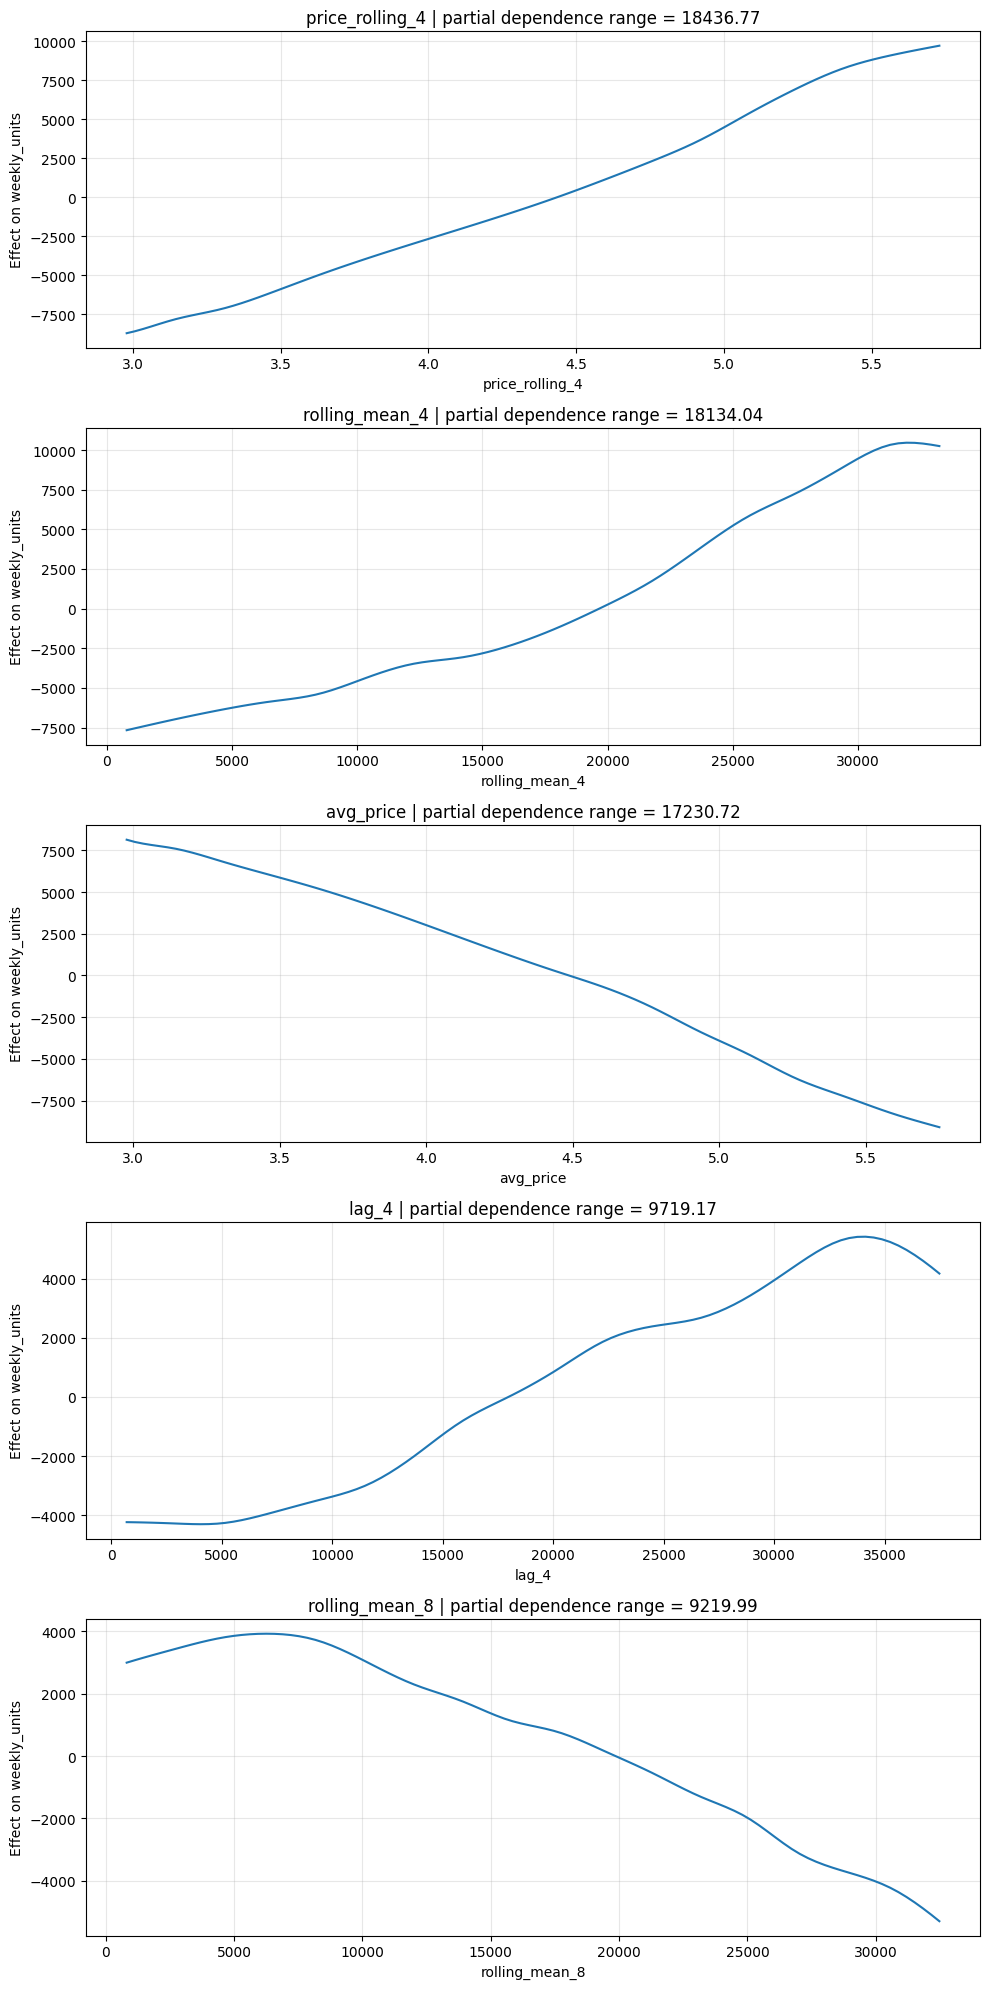

Saved plots to: D:\Ops\IDS705\Final_Project\gam_top5_interpretability
Saved combined plot: gam_top5_interpretability\top5_partial_dependence_combined.png


In [11]:

# -----------------------------
# Save top-5 partial dependence plots
# -----------------------------
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20))
axes = np.atleast_1d(axes)

for ax, row in zip(axes, top5_terms.to_dict("records")):
    i = row["term_index"]
    feature_name = row["feature"]
    feature_idx = feature_cols.index(feature_name)

    XX = gam.generate_X_grid(term=i)
    pdep = gam.partial_dependence(term=i, X=XX)

    ax.plot(XX[:, feature_idx], pdep)
    ax.set_title(f"{feature_name} | partial dependence range = {row['effect_range']:.2f}")
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Effect on weekly_units")
    ax.grid(True, alpha=0.3)

    single_fig = plt.figure(figsize=(8, 4))
    plt.plot(XX[:, feature_idx], pdep)
    plt.title(f"{feature_name} | Effect on weekly_units")
    plt.xlabel(feature_name)
    plt.ylabel("Effect on weekly_units")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    single_path = plot_dir / f"{feature_name}.png"
    plt.savefig(single_path, dpi=200, bbox_inches="tight")
    plt.close(single_fig)

plt.tight_layout()
combined_path = plot_dir / "top5_partial_dependence_combined.png"
plt.savefig(combined_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved plots to: {plot_dir.resolve()}")
print(f"Saved combined plot: {combined_path}")


## Output files created

- `gam_predictions_clean.csv`
- `gam_store_category_metrics.csv`
- `gam_overall_metrics.csv`
- `gam_outputs.xlsx`
- `gam_top5_interpretability/top5_smooth_terms.csv`
- `gam_top5_interpretability/top5_partial_dependence_combined.png`
- individual PNGs for each top-5 smooth parameter
